# Naive Bayes on UFO Sightings Reports

Use sighting descriptions to predict the shape of the UFO.

## 1. Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import os, re
import nltk
from nltk.corpus import stopwords

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/AI Project'
DATA = os.path.join(BASE, 'datasets')
RESULTS = os.path.join(BASE, 'results')
os.makedirs(RESULTS, exist_ok=True)
STOPWORDS = set(stopwords.words('english'))

Mounted at /content/drive


## 2. Load and Explore Data

In [2]:
COLUMNS = ['datetime','city','state','country','shape','duration_seconds',
           'duration_hms','comments','date_posted','latitude','longitude']

df = pd.read_csv(os.path.join(DATA, 'nuforc_sightings.csv'),
                 names=COLUMNS, header=0, low_memory=False)
print(f'Loaded {len(df)} UFO sighting records')

df['comments'] = df['comments'].fillna('').astype(str)
df['shape'] = df['shape'].fillna('unknown').str.lower().str.strip()

top_shapes = df['shape'].value_counts().head(10).index
df = df[df['shape'].isin(top_shapes)].copy()
print(f'Top 10 shapes: {list(top_shapes)}')
print(f'Records with top 10 shapes: {len(df)}')

Loaded 80331 UFO sighting records
Top 10 shapes: ['light', 'triangle', 'circle', 'unknown', 'fireball', 'other', 'sphere', 'disk', 'oval', 'formation']
Records with top 10 shapes: 68201


## 3. Clean Text Data

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(words)

df['clean_comments'] = df['comments'].apply(clean_text)
df = df[df['clean_comments'].str.len() > 10].copy()
print(f'Records after cleaning filter: {len(df)}')

# Sample for performance if needed
if len(df) > 30000:
    df = df.sample(n=30000, random_state=42)
    print(f'Sampled to 30,000 records')

df[['shape', 'clean_comments']].head(5)

Records after cleaning filter: 67477
Sampled to 30,000 records


,shape,clean_comments
8358,other,quot ordinary cloud quot
50798,unknown,traveling north richie saw lights moving left ...
29758,triangle,monday feb black triangular craft seen moving ...
71776,unknown,couple witness bright obj streak overhead hori...
40948,light,two bright orange lights moving slow sky sudde...


## 4. TF-IDF Vectorization & Train/Test Split

In [4]:
X = df['clean_comments']
y = df['shape']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                              min_df=5, max_df=0.7, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f'Vocabulary size: {len(vectorizer.get_feature_names_out())}')

Train: 24000, Test: 6000
Vocabulary size: 5000


## 5. Train Multinomial Naive Bayes

In [5]:
model = MultinomialNB(alpha=0.1)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')

class_names = list(model.classes_)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Test Accuracy: 0.4610
              precision    recall  f1-score   support

      circle       0.39      0.25      0.30       666
        disk       0.49      0.48      0.48       461
    fireball       0.65      0.50      0.57       547
   formation       0.48      0.16      0.24       211
       light       0.43      0.80      0.56      1467
       other       0.27      0.16      0.20       499
        oval       0.62      0.24      0.34       329
      sphere       0.59      0.36      0.45       467
    triangle       0.61      0.62      0.61       697
     unknown       0.30      0.23      0.26       656

    accuracy                           0.46      6000
   macro avg       0.48      0.38      0.40      6000
weighted avg       0.47      0.46      0.44      6000



## 6. Confusion Matrix

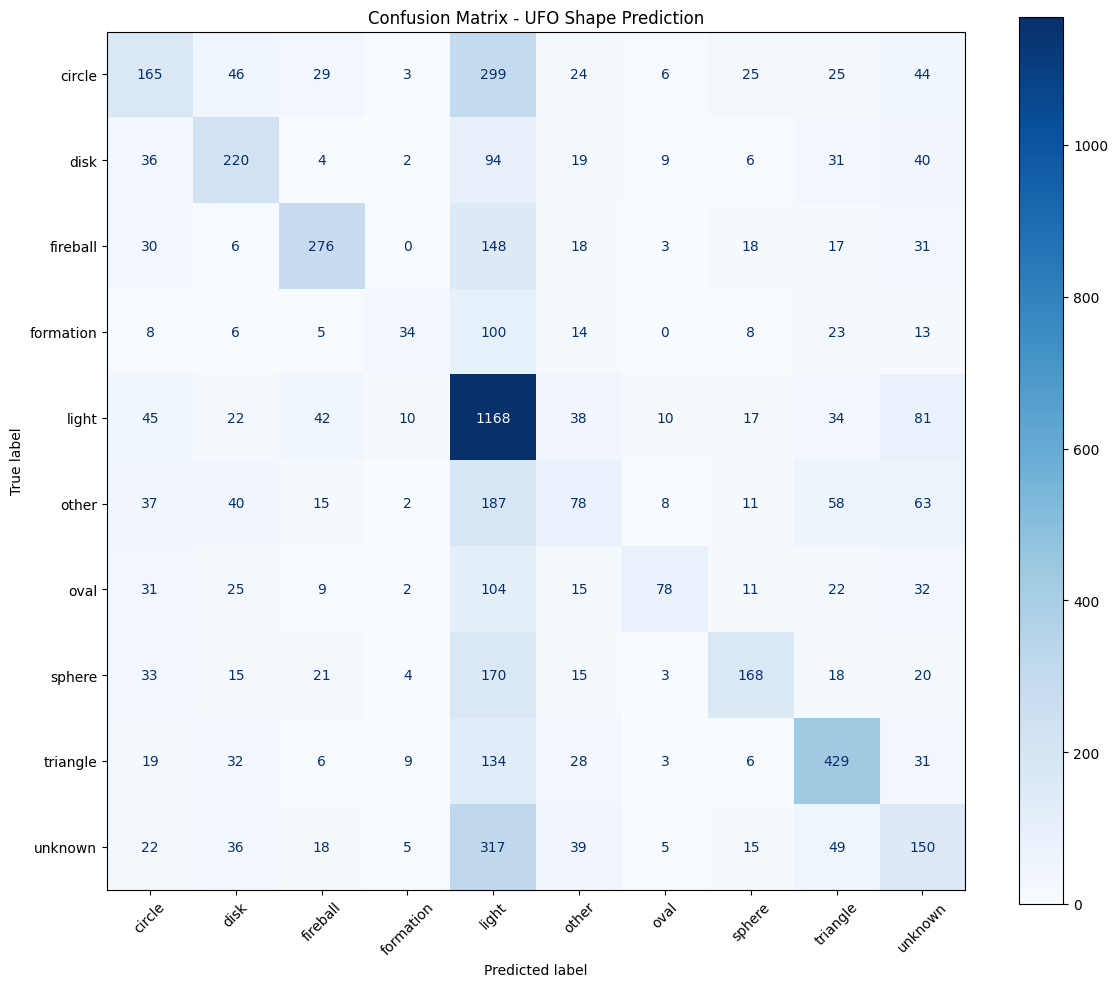

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix - UFO Shape Prediction')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'ufo_confusion_matrix.png'), dpi=100)
plt.show()

## 7. Top Features per Shape

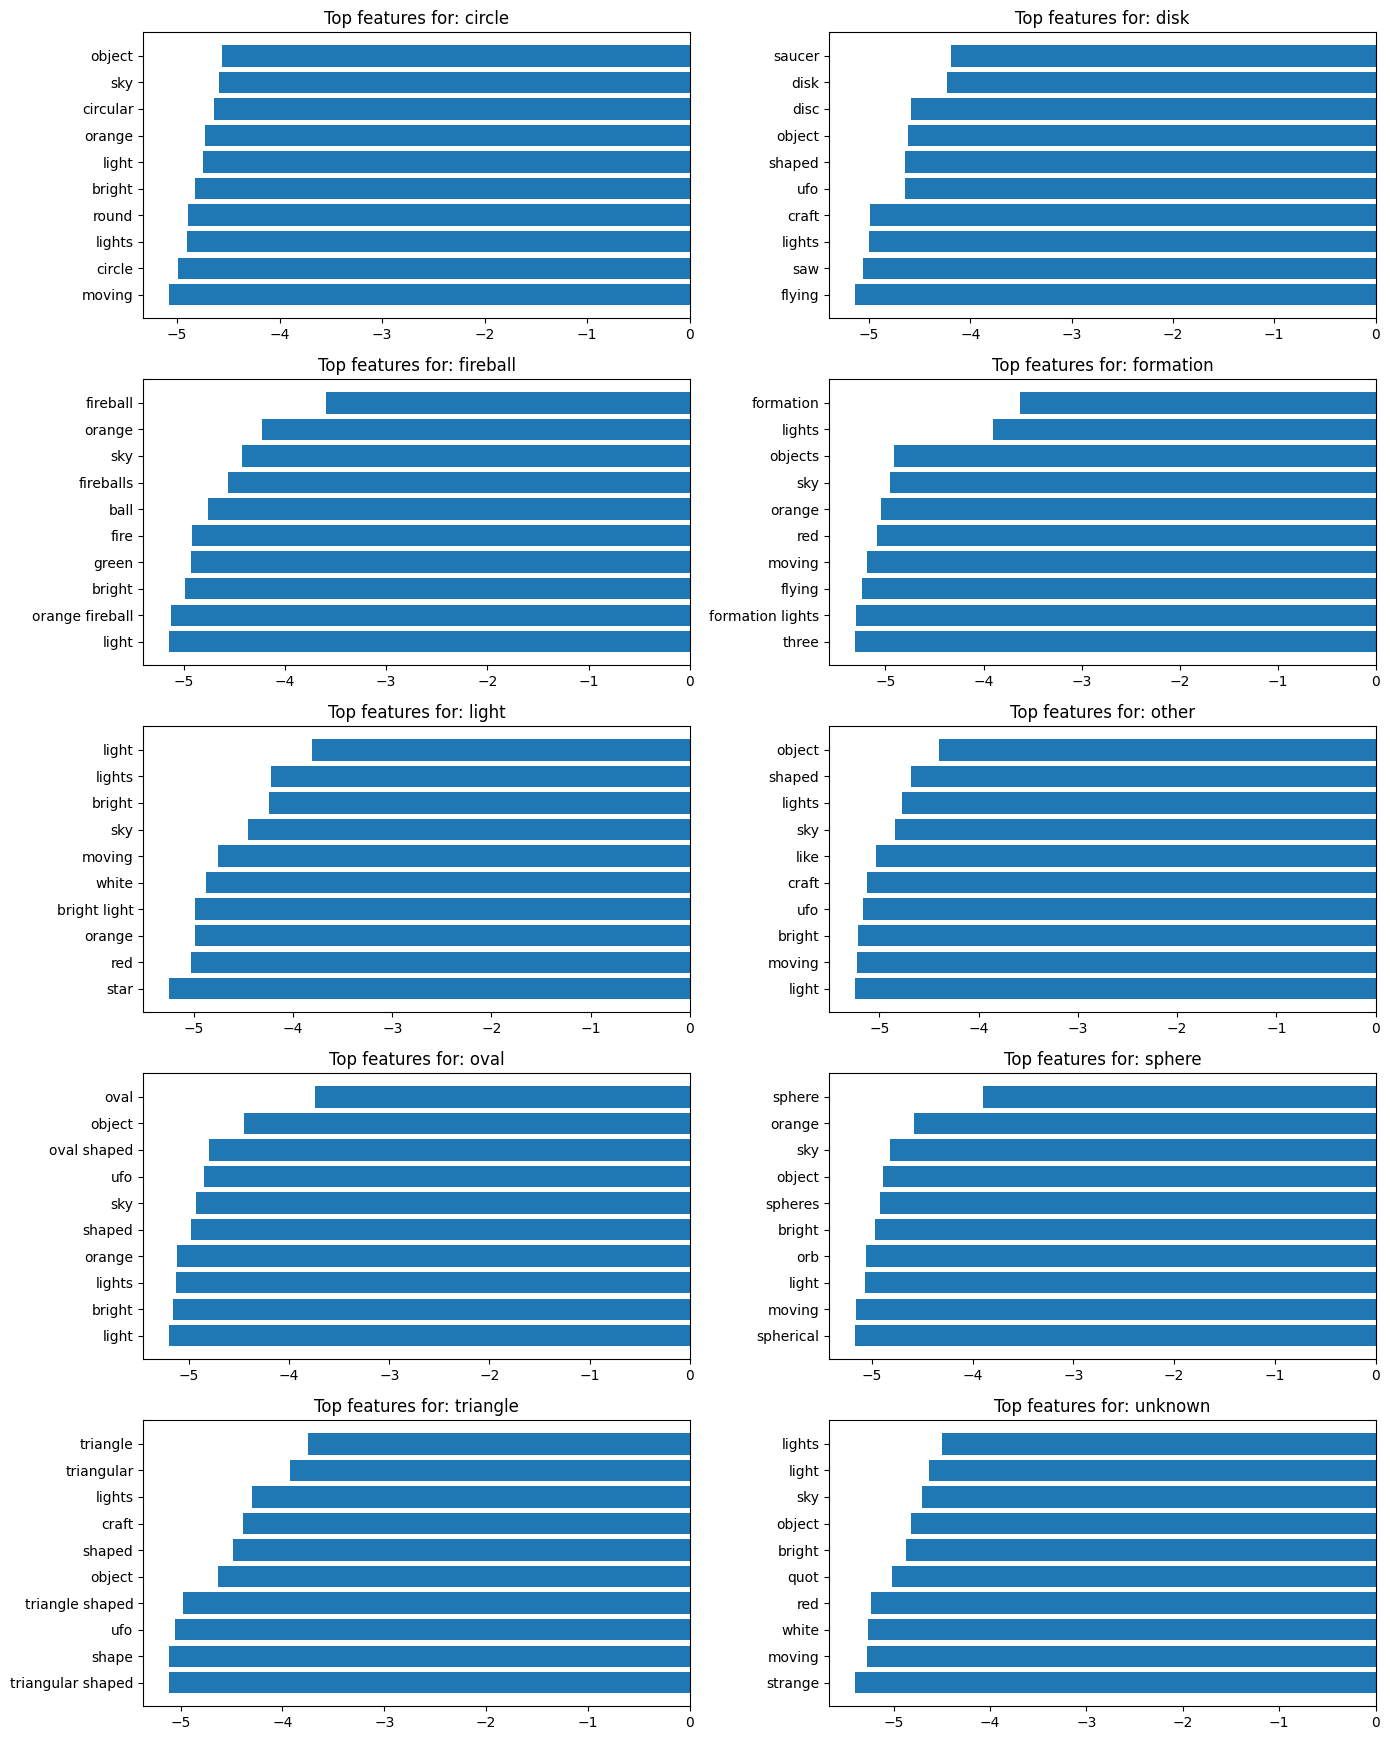

In [7]:
feature_names = vectorizer.get_feature_names_out()
n_classes = min(len(class_names), 10)
n_cols = 2; n_rows = (n_classes + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i in range(n_classes):
    log_probs = model.feature_log_prob_[i]
    top_idx = np.argsort(log_probs)[-10:]
    axes[i].barh(range(10), log_probs[top_idx])
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels([feature_names[j] for j in top_idx])
    axes[i].set_title(f'Top features for: {class_names[i]}')

for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'ufo_top_features.png'), dpi=100)
plt.show()

## 8. Sample Predictions

In [8]:
sample_size = min(5, len(X_test))
sample_idxs = np.random.choice(len(X_test), size=sample_size, replace=False)
X_sample = X_test.iloc[sample_idxs]
y_sample_true = y_test.iloc[sample_idxs]
y_sample_pred = model.predict(vectorizer.transform(X_sample))
for i, idx in enumerate(sample_idxs):
    print(f'True: {y_sample_true.iloc[i]:>12} | Pred: {y_sample_pred[i]:>12}')
    print(f'  Text: {X_sample.iloc[i][:100]}...\n')

True:       circle | Pred:         disk
  Text: object hovoring seconds trees flew away trace sound lights happened afternoon...

True:        light | Pred:      unknown
  Text: exact location deg quot north deg quot thanks gps google earth either back macadam road...

True:       sphere | Pred:        light
  Text: know real interested one ever able tell otherwise...

True:        light | Pred:     fireball
  Text: slow moving object burning dropping pieces burning material...

True:      unknown | Pred:        light
  Text: neon blue red lights plane...



## 9. Summary

- **46.1% accuracy** across 10 shape classes (baseline ~18% for majority 'light' class)
- 'Triangle' and 'Fireball' are most reliably predicted (F1 > 0.55)
- 'Light' has highest recall (80%) — many vague descriptions predict 'light'
- 'Other' and 'Unknown' are hardest to distinguish from similar descriptions
- Future improvement: use word embeddings (Word2Vec/GloVe) instead of TF-IDF